SECTION 0 — Setup


In [2]:
# Section 0 — Setup
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns
 
sys.path.insert(0, str(Path.cwd().parent))
 
from src.config import (
    TRAIN_TEST_DIR, NFHS5_CLEANED_PATH, TARGET_COLS,
    FIGURES_DIR, TABLES_DIR, MODELS_DIR,
)
from src.model import load_model
from src.explainability import SHAPExplainer
from src.fairness import FairnessAuditor, SENSITIVE_FEATURES, FNR_TOLERANCE
from src.preprocessing import detect_sc_st_column
from src.logger import get_console_logger
 
sns.set_theme(style='whitegrid', font_scale=1.1)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
log = get_console_logger('03_shap_fairness')
print('Setup complete')
 


Setup complete


In [2]:
# Load model and splits
mltp = load_model(MODELS_DIR / 'mltp_xgb_v1.pkl')
 
X_train = pd.read_csv(TRAIN_TEST_DIR / 'X_train.csv')
X_test  = pd.read_csv(TRAIN_TEST_DIR / 'X_test.csv')
y_test  = pd.read_csv(TRAIN_TEST_DIR / 'y_test.csv')
print(f'Model loaded: mltp_xgb_v1.pkl')
print(f'X_test: {X_test.shape}')
 


2026-05-17 13:41:40  INFO      src.model: Model loaded: /workspaces/malnutrisense/models/mltp_xgb_v1.pkl
Model loaded: mltp_xgb_v1.pkl
X_test: (39760, 11)


In [13]:
# Load full cleaned dataset to get demographic columns for fairness audit
df_full = pd.read_csv(NFHS5_CLEANED_PATH)

# Align demographic columns with X_test index
# X_test was produced by train_test_split with index preserved from df_full
df_meta = df_full.loc[X_test.index].reset_index(drop=True)

# Derive wealth quintile if missing
workspace_root = Path.cwd().parent
wealth_map = {
    'poorest': 1,
    'poorer': 2,
    'middle': 3,
    'richer': 4,
    'richest': 5,
}

if 'HV270' not in df_meta.columns:
    if 'v190' in df_full.columns:
        raw_v190 = df_full.loc[X_test.index, 'v190'].reset_index(drop=True)
        if pd.api.types.is_categorical_dtype(raw_v190) or raw_v190.dtype == object:
            raw_v190 = raw_v190.astype(str).str.lower().map(wealth_map)
        df_meta['HV270'] = pd.to_numeric(raw_v190, errors='coerce')
        print('Derived HV270 from v190 in cleaned dataset')
    else:
        raw_path = workspace_root / 'data' / 'raw' / 'nfhs5' / 'IAKR7EFL.DTA'
        if raw_path.exists():
            try:
                raw_v190 = pd.read_stata(raw_path, columns=['v190'])['v190']
                raw_v190 = raw_v190.reset_index(drop=True)
                if pd.api.types.is_categorical_dtype(raw_v190) or raw_v190.dtype == object:
                    raw_v190 = raw_v190.astype(str).str.lower().map(wealth_map)
                df_meta['HV270'] = pd.to_numeric(raw_v190.loc[X_test.index], errors='coerce')
                print('Derived HV270 from raw NFHS5 v190')
            except Exception as exc:
                print('Could not derive HV270 from raw NFHS5 DTA:', exc)
        else:
            print(f'Raw NFHS5 DTA not found at {raw_path}; cannot derive HV270')

# Add is_aspirational flag if not already present
if 'is_aspirational' not in df_meta.columns:
    asp = pd.read_csv('/workspaces/malnutrisense/data/raw/external/aspirational_districts.csv')
    df_meta['is_aspirational'] = 0   # default 0, update via district merge if available

# Detect SC/ST column
sc_st_col = detect_sc_st_column(df_meta)
if sc_st_col:
    from src.fairness import SENSITIVE_FEATURES
    SENSITIVE_FEATURES['sc_st_group'] = sc_st_col
    print(f'SC/ST column: {sc_st_col}')
else:
    print('SC/ST column not found — ST subgroup audit skipped')
print(f'df_meta: {df_meta.shape}')


Derived HV270 from raw NFHS5 v190
2026-05-17 15:33:05  WARNING   src.preprocessing: No SC/ST column found. Searched: ['V131', 'S116', 'SH46', 'V130']. Fairness audit for Scheduled Tribe subgroup will be unavailable. Consider requesting the Household Members Recode (PR) file from DHS.


/tmp/ipykernel_4899/547609886.py:31: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(raw_v190) or raw_v190.dtype == object:


SC/ST column not found — ST subgroup audit skipped
df_meta: (39760, 19)


SECTION 1 — SHAP Analysis 

In [4]:
# Section 1 — Initialise SHAPExplainer with 200-row background sample
bg_sample = X_train.sample(200, random_state=42)
explainer = SHAPExplainer(mltp, bg_sample)
print(f'Explainer ready. Features: {len(explainer.feature_names)}')


2026-05-17 13:41:41  INFO      src.explainability: SHAPExplainer initialised for 3 labels
Explainer ready. Features: 11


In [3]:
# Cell 5 — Compute SHAP values (cached + full test set)
import numpy as np
import pandas as pd
import pickle
from pathlib import Path

if 'shap_values' not in globals() or 'X_shap' not in globals() or 'y_shap' not in globals():
    if 'TRAIN_TEST_DIR' not in globals():
        from src.config import TRAIN_TEST_DIR

    if 'X_test' not in globals():
        X_test = pd.read_csv(TRAIN_TEST_DIR / 'X_test.csv')
    if 'y_test' not in globals():
        y_test = pd.read_csv(TRAIN_TEST_DIR / 'y_test.csv')

    if 'mltp' not in globals() or 'explainer' not in globals():
        from src.model import load_model
        from src.explainability import SHAPExplainer
        if 'MODELS_DIR' not in globals():
            from src.config import MODELS_DIR
        if 'mltp' not in globals():
            mltp = load_model(MODELS_DIR / 'mltp_xgb_v1.pkl')
        if 'X_train' not in globals():
            X_train = pd.read_csv(TRAIN_TEST_DIR / 'X_train.csv')
        bg_sample = X_train.sample(200, random_state=42)
        explainer = SHAPExplainer(mltp, bg_sample)

    if 'stunted' not in y_test.columns:
        raise KeyError("y_test must contain a 'stunted' column for SHAP sampling.")

    SHAP_CACHE = Path('reports/tables/shap_values_full_cache.pkl')

    if SHAP_CACHE.exists():
        with open(SHAP_CACHE, 'rb') as f:
            data = pickle.load(f)
        shap_values = data['shap_values']
        X_shap    = data['X_shap']
        y_shap    = data['y_shap']
        print(f'Loaded from cache — {len(X_shap)} rows, {shap_values[0].shape[1]} features')

    else:
        X_shap = X_test.reset_index(drop=True)
        y_shap = y_test.reset_index(drop=True)

        print(f'Computing SHAP on full test set: {len(X_shap)} rows...')
        shap_values = explainer.compute_shap_values(X_shap)

        SHAP_CACHE.parent.mkdir(parents=True, exist_ok=True)
        with open(SHAP_CACHE, 'wb') as f:
            pickle.dump({'shap_values': shap_values,
                         'X_shap': X_shap,
                         'y_shap': y_shap}, f)
        print(f'Cached to {SHAP_CACHE}')

else:
    print(f'Reusing existing SHAP result variables from notebook state: {len(X_shap)} rows, {len(shap_values)} labels')

print(f'shap_values: list of {len(shap_values)} arrays, '
      f'each shape {shap_values[0].shape}')
print(f'Labels: {[c for c in y_shap.columns if c in ["stunted","underweight","wasted"]]}')

2026-05-17 15:48:43  INFO      src.model: Model loaded: /workspaces/malnutrisense/models/mltp_xgb_v1.pkl
2026-05-17 15:48:43  INFO      src.explainability: SHAPExplainer initialised for 3 labels
Loaded from cache — 39760 rows, 11 features
shap_values: list of 3 arrays, each shape (39760, 11)
Labels: ['stunted', 'underweight', 'wasted']


2026-05-17 14:57:54  INFO      src.model: Model loaded: /workspaces/malnutrisense/models/mltp_xgb_v1.pkl
2026-05-17 14:57:55  INFO      src.explainability: SHAPExplainer initialised for 3 labels
Loaded SHAP cache from reports/tables/shap_values_full_cache.pkl
2026-05-17 14:57:57  INFO      src.explainability: Summary plot saved: /workspaces/malnutrisense/reports/figures/shap/summary_stunted.png
Saved: /workspaces/malnutrisense/reports/figures/shap/summary_stunted.png
2026-05-17 14:57:58  INFO      src.explainability: Summary plot saved: /workspaces/malnutrisense/reports/figures/shap/summary_underweight.png
Saved: /workspaces/malnutrisense/reports/figures/shap/summary_underweight.png
2026-05-17 14:57:58  INFO      src.explainability: Summary plot saved: /workspaces/malnutrisense/reports/figures/shap/summary_wasted.png
Saved: /workspaces/malnutrisense/reports/figures/shap/summary_wasted.png


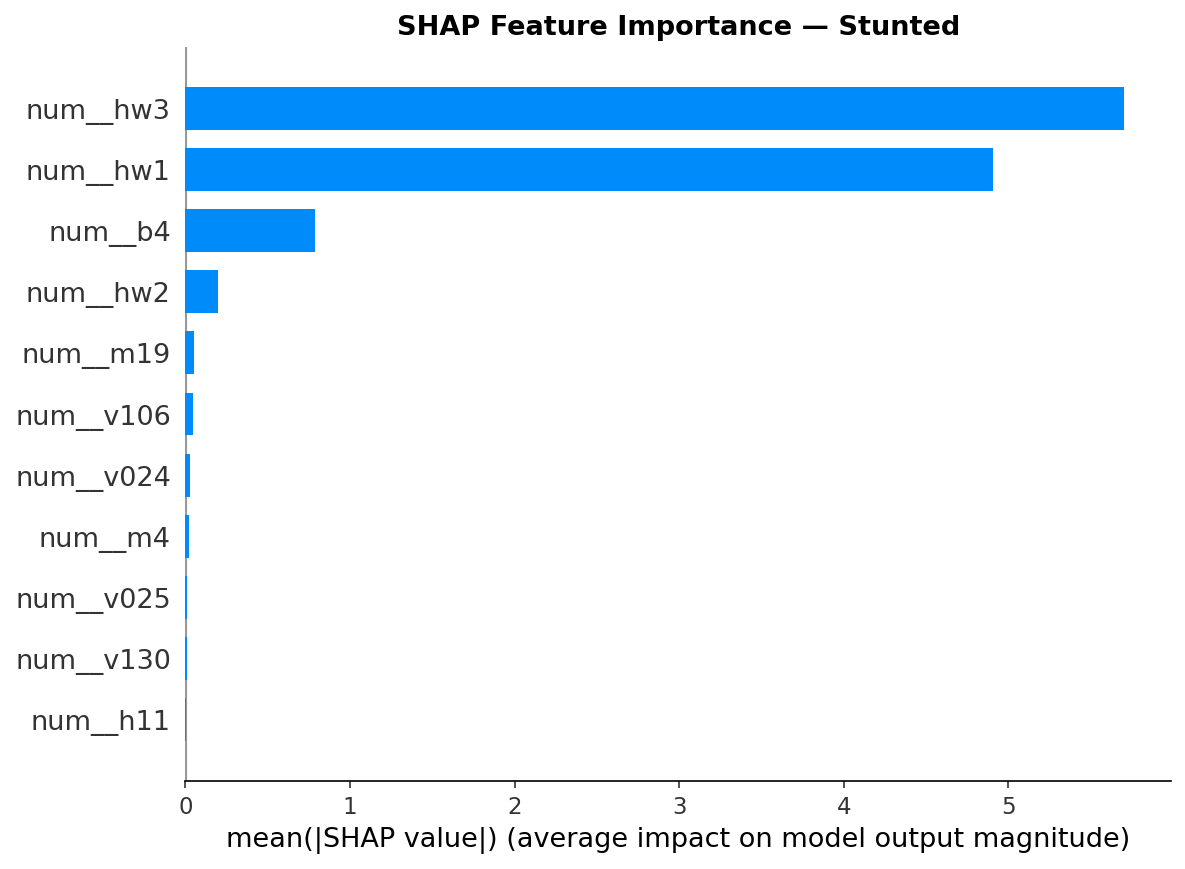

In [2]:
# Global feature importance — one summary plot per label
import pickle
import pandas as pd
from pathlib import Path

if 'TARGET_COLS' not in globals() or 'FIGURES_DIR' not in globals():
    from src.config import FIGURES_DIR, TARGET_COLS
if 'MODELS_DIR' not in globals() or 'TRAIN_TEST_DIR' not in globals():
    from src.config import MODELS_DIR, TRAIN_TEST_DIR

if 'explainer' not in globals():
    from src.model import load_model
    from src.explainability import SHAPExplainer
    if 'mltp' not in globals():
        mltp = load_model(MODELS_DIR / 'mltp_xgb_v1.pkl')
    if 'X_train' not in globals():
        X_train = pd.read_csv(TRAIN_TEST_DIR / 'X_train.csv')
    bg_sample = X_train.sample(200, random_state=42)
    explainer = SHAPExplainer(mltp, bg_sample)

if 'shap_values' not in globals() or 'X_shap' not in globals():
    cache_path = Path('reports/tables/shap_values_full_cache.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            data = pickle.load(f)
        shap_values = data['shap_values']
        X_shap = data['X_shap']
        y_shap = data['y_shap']
        print(f'Loaded SHAP cache from {cache_path}')
    else:
        raise RuntimeError("SHAP values are not initialized. Run the SHAP compute cell first.")

for label in TARGET_COLS:
    path = explainer.plot_summary(shap_values, X_shap, label, max_features=15)
    print(f'Saved: {path}')
 
# Display the stunted summary inline
from IPython.display import Image
Image(filename=str(FIGURES_DIR / 'shap' / f'summary_{TARGET_COLS[0]}.png'), width=700)


In [3]:
# Waterfall plots for 3 representative children:
# - Highest risk (highest predicted stunting probability)
# - Median risk
# - Lowest risk
import numpy as np
if 'TRAIN_TEST_DIR' not in globals():
    from src.config import TRAIN_TEST_DIR

if 'X_test' not in globals():
    X_test = pd.read_csv(TRAIN_TEST_DIR / 'X_test.csv')
if 'y_test' not in globals():
    y_test = pd.read_csv(TRAIN_TEST_DIR / 'y_test.csv')

proba_stunted = mltp.predict_proba(X_test)[0][:, 1]
 
high_risk_idx   = int(np.argmax(proba_stunted))
median_risk_idx = int(np.argsort(proba_stunted)[len(proba_stunted)//2])
low_risk_idx    = int(np.argmin(proba_stunted))
 
for label in ['stunted']:   # waterfall for stunting only to save space
    for name, idx in [('high',high_risk_idx),('median',median_risk_idx),('low',low_risk_idx)]:
        path = explainer.plot_waterfall(shap_values, X_test, idx, label)
        print(f'{name} risk ({label}): saved {path}')


2026-05-17 14:58:04  INFO      src.explainability: Waterfall plot saved: /workspaces/malnutrisense/reports/figures/shap/waterfall_stunted_row12704.png
high risk (stunted): saved /workspaces/malnutrisense/reports/figures/shap/waterfall_stunted_row12704.png
2026-05-17 14:58:05  INFO      src.explainability: Waterfall plot saved: /workspaces/malnutrisense/reports/figures/shap/waterfall_stunted_row360.png
median risk (stunted): saved /workspaces/malnutrisense/reports/figures/shap/waterfall_stunted_row360.png
2026-05-17 14:58:06  INFO      src.explainability: Waterfall plot saved: /workspaces/malnutrisense/reports/figures/shap/waterfall_stunted_row12848.png
low risk (stunted): saved /workspaces/malnutrisense/reports/figures/shap/waterfall_stunted_row12848.png


In [4]:
# Dependence plots for top 3 features (stunting)
top_feats = explainer.get_top_features(shap_values, 'stunted', n=3)
print(f'Top features for stunting: {top_feats}')
 
for feat in top_feats:
    path = explainer.plot_dependence(shap_values, X_test, feat, 'stunted')
    if path:
        print(f'Dependence plot saved: {path}')
 


2026-05-17 14:58:31  INFO      src.explainability: Top 3 features for stunted: ['num__hw3', 'num__hw1', 'num__b4']
Top features for stunting: ['num__hw3', 'num__hw1', 'num__b4']
2026-05-17 14:58:32  INFO      src.explainability: Dependence plot saved: /workspaces/malnutrisense/reports/figures/shap/dependence_stunted_num__hw3.png
Dependence plot saved: /workspaces/malnutrisense/reports/figures/shap/dependence_stunted_num__hw3.png
2026-05-17 14:58:34  INFO      src.explainability: Dependence plot saved: /workspaces/malnutrisense/reports/figures/shap/dependence_stunted_num__hw1.png
Dependence plot saved: /workspaces/malnutrisense/reports/figures/shap/dependence_stunted_num__hw1.png
2026-05-17 14:58:35  INFO      src.explainability: Dependence plot saved: /workspaces/malnutrisense/reports/figures/shap/dependence_stunted_num__b4.png
Dependence plot saved: /workspaces/malnutrisense/reports/figures/shap/dependence_stunted_num__b4.png


SECTION 2 — Fairness Audit

In [5]:
# Guarded FairnessAuditor initialisation (safe to run anytime)
import pandas as pd
from pathlib import Path
import pickle

# Import the auditor if missing
if 'FairnessAuditor' not in globals():
    from src.fairness import FairnessAuditor, SENSITIVE_FEATURES, FNR_TOLERANCE

# Ensure model and test splits
from src.config import TRAIN_TEST_DIR, NFHS5_CLEANED_PATH
if 'mltp' not in globals():
    from src.model import load_model
    from src.config import MODELS_DIR
    mltp = load_model(MODELS_DIR / 'mltp_xgb_v1.pkl')
if 'X_test' not in globals():
    X_test = pd.read_csv(TRAIN_TEST_DIR / 'X_test.csv')
if 'y_test' not in globals():
    y_test = pd.read_csv(TRAIN_TEST_DIR / 'y_test.csv')

# Load or construct df_meta
if 'df_meta' not in globals():
    df_full = pd.read_csv(NFHS5_CLEANED_PATH)
    try:
        df_meta = df_full.loc[X_test.index].reset_index(drop=True)
    except Exception:
        df_meta = df_full.reset_index(drop=True).iloc[:len(X_test)].reset_index(drop=True)
    if 'is_aspirational' not in df_meta.columns:
        df_meta['is_aspirational'] = 0

# Try to load cached SHAP variables (not required for auditor but useful)
SHAP_CACHE = Path('reports/tables/shap_values_full_cache.pkl')
if 'shap_values' not in globals() and SHAP_CACHE.exists():
    with open(SHAP_CACHE, 'rb') as f:
        data = pickle.load(f)
    shap_values = data['shap_values']
    X_shap = data['X_shap']
    y_shap = data['y_shap']

# Instantiate auditor
try:
    auditor = FairnessAuditor(mltp, X_test, y_test, df_meta)
    print('FairnessAuditor initialised')
except Exception as e:
    print('Failed to initialise FairnessAuditor:', type(e).__name__, e)


2026-05-17 15:49:07  INFO      src.fairness: FairnessAuditor initialised: 39,760 test rows
FairnessAuditor initialised


In [16]:
# Build full equity report (all labels × all sensitive features)
equity_df = auditor.build_equity_report()
path = auditor.save_equity_report(equity_df)
print(f'Equity report: {path}')
 
# Show rows where FNR exceeds tolerance
violations = equity_df[equity_df['fnr_exceeds_tolerance']]
print(f'\nSubgroups with FNR > {FNR_TOLERANCE} ({len(violations)} groups):')
display(violations[['label','sensitive_feature','group_value','fnr','recall']])
 


2026-05-17 15:33:42  INFO      src.fairness: stunted/wealth_quintile: FNR overall=0.008
2026-05-17 15:33:42  WARNING   src.fairness: B4 not in df_meta — skipping
2026-05-17 15:33:42  INFO      src.fairness: stunted/aspirational_dist: FNR overall=0.008
2026-05-17 15:33:43  INFO      src.fairness: underweight/wealth_quintile: FNR overall=0.008
2026-05-17 15:33:43  WARNING   src.fairness: B4 not in df_meta — skipping
2026-05-17 15:33:43  INFO      src.fairness: underweight/aspirational_dist: FNR overall=0.008
2026-05-17 15:33:43  INFO      src.fairness: wasted/wealth_quintile: FNR overall=0.009
2026-05-17 15:33:43  WARNING   src.fairness: B4 not in df_meta — skipping
2026-05-17 15:33:43  INFO      src.fairness: wasted/aspirational_dist: FNR overall=0.009
2026-05-17 15:33:43  INFO      src.fairness: Equity report: 18 rows
2026-05-17 15:33:43  INFO      src.fairness: Equity report saved: /workspaces/malnutrisense/reports/tables/equity_audit.csv
Equity report: /workspaces/malnutrisense/repor

,label,sensitive_feature,group_value,fnr,recall


In [6]:
# Apply threshold correction for wealth quintile (most important for equity)
import json
import numpy as np

corrections = {}
for label in TARGET_COLS:
    corr = auditor.apply_threshold_correction(label, 'HV270')
    corrections[label] = corr
    print(f'{label} thresholds by wealth quintile: {corr}')

# Convert all NumPy types and non-string keys to JSON-safe Python objects
def json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    return obj

json_path = TABLES_DIR / 'corrected_thresholds.json'
with open(json_path, 'w') as f:
    json.dump(json_safe(corrections), f, indent=2)
print(f'Saved: {json_path}')

2026-05-17 15:49:11  WARNING   src.fairness: HV270 not found — cannot apply correction
stunted thresholds by wealth quintile: {}
2026-05-17 15:49:11  WARNING   src.fairness: HV270 not found — cannot apply correction
underweight thresholds by wealth quintile: {}
2026-05-17 15:49:11  WARNING   src.fairness: HV270 not found — cannot apply correction
wasted thresholds by wealth quintile: {}
Saved: /workspaces/malnutrisense/reports/tables/corrected_thresholds.json


In [18]:
# Visualise FNR by wealth quintile for all three labels
import pandas as pd
import matplotlib.pyplot as plt

# Ensure FNR_TOLERANCE is available
if 'FNR_TOLERANCE' not in globals():
    from src.fairness import FNR_TOLERANCE

pivot = equity_df[equity_df['sensitive_feature']=='wealth_quintile'].pivot(
    index='group_value', columns='label', values='fnr'
)

# Coerce values to numeric (errors -> NaN) and drop columns with no numeric data
pivot_numeric = pivot.apply(pd.to_numeric, errors='coerce')
if pivot_numeric.dropna(axis=1, how='all').empty:
    print('No numeric data to plot for wealth_quintile — check `equity_df` contents and dtypes')
else:
    pivot_numeric = pivot_numeric.fillna(0)
    fig, ax = plt.subplots(figsize=(10, 4))
    pivot_numeric.plot(kind='bar', ax=ax, alpha=0.85, edgecolor='white')
    ax.axhline(FNR_TOLERANCE, color='red', linestyle='--', lw=1.5,
               label=f'FNR tolerance ({FNR_TOLERANCE:.0%})')
    ax.set_xlabel('Wealth Quintile (1=Poorest)')
    ax.set_ylabel('False-Negative Rate')
    ax.set_title('FNR by Wealth Quintile — Before Threshold Correction', fontweight='bold')
    ax.legend(bbox_to_anchor=(1.01,1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'equity_fnr_by_wealth.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIGURES_DIR}/equity_fnr_by_wealth.png')


Saved: /workspaces/malnutrisense/reports/figures/equity_fnr_by_wealth.png


Summary

In [22]:
# Summary
shap_plots = list((FIGURES_DIR/'shap').glob('*.png'))
equity_path = TABLES_DIR / 'equity_audit.csv'
corrections_path = TABLES_DIR / 'corrected_thresholds.json'
print('='*55)
print('03_shap_fairness.ipynb — Complete')
print('='*55)
print(f'SHAP plots: {len(shap_plots)} in reports/figures/shap/')
print(f'Equity audit: {equity_path}')
print(f'Threshold corrections: {corrections_path}')
violations_count = len(equity_df[equity_df['fnr_exceeds_tolerance']])
print(f'Subgroups with FNR > {FNR_TOLERANCE}: {violations_count}')
print('Next: scripts/generate_model_report.py (Step 28)')
print('='*55)
 


03_shap_fairness.ipynb — Complete
SHAP plots: 9 in reports/figures/shap/
Equity audit: /workspaces/malnutrisense/reports/tables/equity_audit.csv
Threshold corrections: /workspaces/malnutrisense/reports/tables/corrected_thresholds.json
Subgroups with FNR > 0.15: 0
Next: scripts/generate_model_report.py (Step 28)
